In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Load dataset
housing = fetch_california_housing()

data = pd.DataFrame(housing.data,
columns=housing.feature_names)
data["Price"] = housing.target

In [3]:
# select one feature
X = data[['AveRooms']].values
y = data['Price'].values

In [4]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42
)

In [5]:
# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
w = 0
b = 0

learning_rate = 0.01
epochs = 1000

n = len(X_train_scaled)
cost_history = []
for i in range(epochs):
    y_pred = w * X_train_scaled.flatten() + b
    dw = (1/n) * np.sum((y_pred - y_train) * X_train_scaled.flatten())
    db = (1/n) * np.sum(y_pred - y_train)
    w = w - learning_rate * dw
    b = b - learning_rate * db

    cost = (1/(2*n)) * np.sum((y_pred - y_train) ** 2)
    cost_history.append(cost)
    if i % 100 == 0:
        print(f"Epoch {i}, Cost = {cost:.4f}")
y_pred_gd = w * X_test_scaled.flatten() + b

Epoch 0, Cost = 2.8149
Epoch 100, Cost = 0.9414
Epoch 200, Cost = 0.6904
Epoch 300, Cost = 0.6568
Epoch 400, Cost = 0.6523
Epoch 500, Cost = 0.6517
Epoch 600, Cost = 0.6516
Epoch 700, Cost = 0.6516
Epoch 800, Cost = 0.6516
Epoch 900, Cost = 0.6516


In [7]:
print("Gradient Descent")
print("----------------")
print("Weight: ", w)
print("Bias: ", b)
print("MSE: ", mean_squared_error(y_test, y_pred_gd))
print("R2 Score: ", r2_score(y_test, y_pred_gd))

Gradient Descent
----------------
Weight:  0.18323090648660517
Bias:  2.0718574888450205
MSE:  1.292327655590046
R2 Score:  0.013798228607320828


In [8]:
# ===================
# Normal Equation
# ===================
X_train_ne = np.c_[np.ones((len(X_train),1)), X_train]
X_test_ne = np.c_[np.ones((len(X_test),1)), X_test]

theta = np.linalg.inv(X_train_ne.T @ X_train_ne) @ X_train_ne.T @ y_train

y_pred_ne = X_test_ne @ theta

In [9]:
print("\nNormal Equation")
print("-------------------")
print("Intercept: ", theta[0])
print("Slope: ", theta[1])
print("MSE: ", mean_squared_error(y_test, y_pred_ne))
print("R2 Score: ", r2_score(y_test, y_pred_ne))


Normal Equation
-------------------
Intercept:  1.6547622685968417
Slope:  0.07675558963126736
MSE:  1.2923314440807299
R2 Score:  0.013795337532284901


In [10]:
# ===================
# Sort values for smooth regression line
# ===================
sort_axis = np.argsort(X_test.flatten())
X_sorted = X_test[sort_axis]
y_pred_ne_sorted = y_pred_ne[sort_axis]

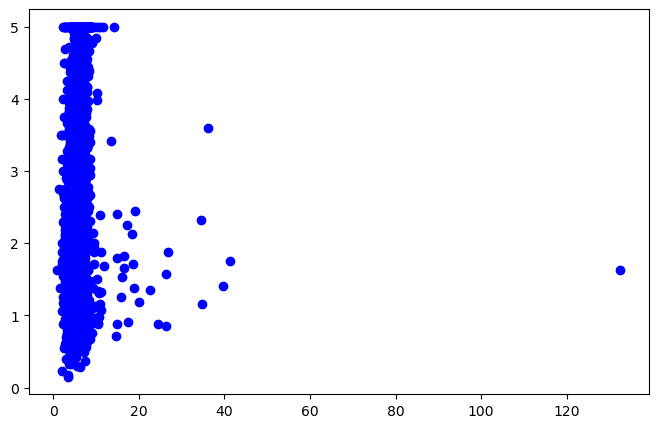

In [11]:
# ===================
# Regression Line Visualization
# ===================
# Sort smooth values for a snooth line

index = np.argsort(X_test.flatten())
plt.figure(figsize=(8, 5))

# Scatter plot
plt.scatter(X_test, y_test, color='blue', label='Actual Data')

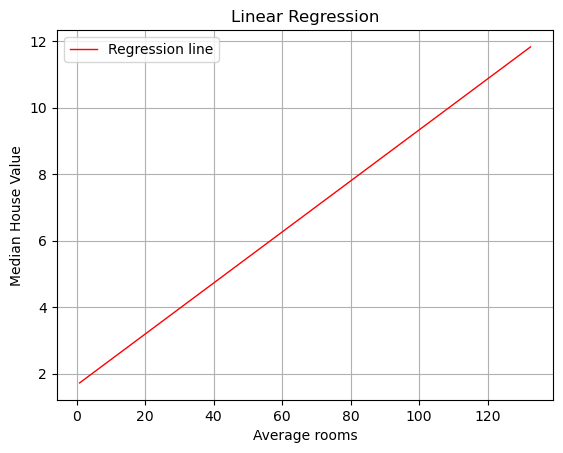

In [12]:
# Regression line
plt.plot(
    X_test.flatten()[index],
    y_pred_ne[index],
    color = 'red',
    linewidth = 1,
    label = 'Regression line'
)
plt.title("Linear Regression")
plt.xlabel("Average rooms")
plt.ylabel("Median House Value")
plt.legend()
plt.grid(True)
plt.show()

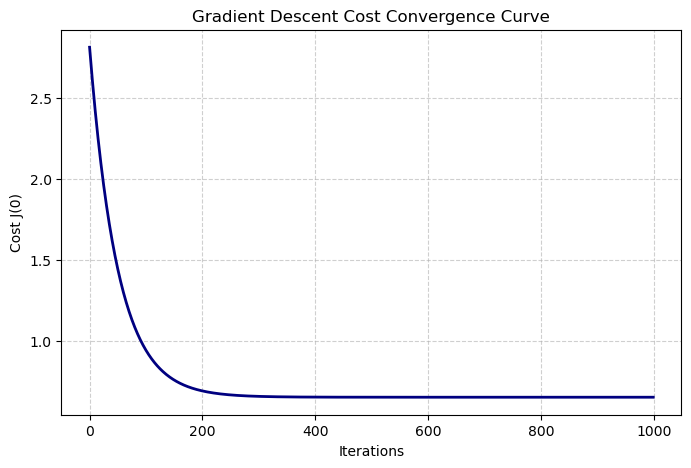

In [13]:
# ===================
# Cost Convergence Curve
# ===================

plt.figure(figsize=(8, 5))

plt.plot(cost_history, color='navy', linewidth=2)

plt.title("Gradient Descent Cost Convergence Curve")
plt.xlabel("Iterations")
plt.ylabel("Cost J(0)")
plt.grid(True, linestyle = '--', alpha=0.6)
plt.show()
